In [29]:
import numpy as np
import pandas as pd
import timeit
import sys
# Add measurement mcts python package to path
sys.path.append('../src/measurement_mcts')
from measurement_mcts.mcts.mcts import mcts_search, get_best_trajectory
from measurement_mcts.mcts.tree_viz import render_pyvis
from measurement_mcts.state_evaluation.reinforcement_learning import MCTSRLWrapper, plot_state_image
from measurement_mcts.environment.measurement_control_env import MeasurementControlEnvironment
from measurement_mcts.utils.utils import wrapped_angle_diff

env = MeasurementControlEnvironment(init_reset=False)

Toy Measurement Control Initialized


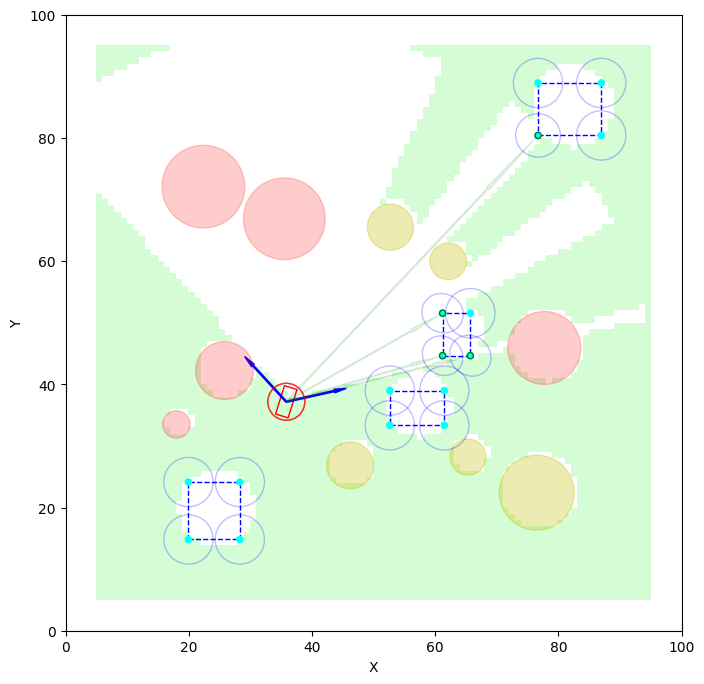

In [30]:
env.reset();
env.draw_state(env.get_state())

In [46]:
def reward_to_go_heuristic(state, range_weight=1, angle_weight=1):
    # Pull out elements of state
    car_state, object_df, explore_grid, horizon = state

    # Pull out car position and yaw
    car_pos = car_state[0:2]
    car_yaw = car_state[3]

    # Pull out only rows with object_type is ooi
    ooi_df = object_df[object_df['object_type'] == 'ooi']

    # Get a list of all points from all oois and calculate trace of covariance matrix
    ooi_points = np.vstack(ooi_df['points'])
    ooi_covariances = np.vstack(ooi_df['covariances'])
    ooi_traces = np.trace(ooi_covariances, axis1=1, axis2=2)

    range = np.linalg.norm(ooi_points - car_pos, axis=1)  # Distance from car to observation
    bearing = np.arctan2(ooi_points[:,1] - car_pos[1], ooi_points[:,0] - car_pos[0]) # Direction of observation
    abs_angle_from_car = np.abs(wrapped_angle_diff(bearing, car_yaw))  # Angle between center of sensor and observation
    
    # print(f'Car position: {car_pos}')
    # print(f'Car yaw: {np.degrees(car_yaw)}')
    # print(ooi_points[:4])
    # print(ooi_traces[:4])
    print(range)
    print(f'Range sum: {np.sum(range)}')
    # print(np.degrees(bearing[:4]))
    # print(np.degrees(abs_angle_from_car))
    # print(f'Angle sum: {np.sum(abs_angle_from_car)}')
    
    # Calculate reward to go heuristic
    reward_to_go = ooi_traces * ((range_weight / range) +  (angle_weight / abs_angle_from_car))
    
    print('Reward to go:')
    print(reward_to_go)
    print(f'Total reward: {np.sum(reward_to_go)}')

state = env.get_state()
reward_to_go_heuristic(state, range_weight=0.1, angle_weight=0)#.001)

[17.24447523 25.93108419 25.71136881 16.91228207 27.42266069 23.59099926
 15.06183489 20.55057039 59.48962896 66.95490756 72.74964051 65.94366157
 26.45098752 30.79950771 33.15953739 29.16504732]
Range sum: 557.138194074211
Reward to go:
[0.09278334 0.06170201 0.06222928 0.0946058  0.05834591 0.06782248
 0.10622876 0.07785672 0.02408468 0.02389668 0.02199324 0.02426314
 0.04904247 0.0433145  0.04825158 0.04491028]
Total reward: 0.9013308538440945
